In [44]:
# IMPORTS
# ============================================================================

# Standard Library
import os, glob, json, yaml, time, math, random, warnings
from pathlib import Path
from datetime import datetime
from collections import defaultdict, Counter

# Data Science & Visualization
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

# Audio Processing
import librosa
from pydub import AudioSegment
from scipy.signal import butter, lfilter

# PyTorch & Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast
from torch.utils.tensorboard import SummaryWriter

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_recall_fscore_support

# Parallel Processing
from joblib import Parallel, delayed

# ============================================================================
# CONFIGURATION & SETUP
# ============================================================================

warnings.filterwarnings("ignore", category=FutureWarning)

# Global Constants
SUPPORTED_EXTS = (".wav", ".mp3", ".m4a", ".wma")
RANDOM_SEED = 42

# Reproducibility
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# PATHS
BASE_DIR = Path(__file__).parent if '__file__' in globals() else Path.cwd()
data_root = BASE_DIR / "Recordings_1"
output_dir = BASE_DIR / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

if not data_root.exists():
    alt = BASE_DIR.parent / "IML-PW" / "Recordings"
    if alt.exists():
        data_root = alt
    else:
        raise FileNotFoundError(f"Recordings folder not found")

print(f"📁 data_root: {data_root}\n📁 output_dir: {output_dir}")

# ============================================================================
# LABELING MODE SELECTION
# ============================================================================
# Choose ONE of the following modes:
#
# "binary"     - Labels: 0 (outsider), 1 (group member)
#                Use case: Simple access control (allowed vs not allowed)
#                Model output: 2 classes
#
# "speaker_id" - Labels: 0, 1, 2, 3, ... (unique speaker IDs)
#                Use case: Speaker identification + access control via embeddings
#                Model output: N classes (one per speaker)
#                Recommended for: Identifying WHO is speaking + access control
# ============================================================================

LABEL_MODE = "binary"  # Options: "binary" or "speaker_id"

print(f"\n🏷️  LABEL MODE: {LABEL_MODE}")

# ============================================================================
# HYPERPARAMETERS
sr = 16000
n_mels = 64
n_fft = 2048
hop_length = 512
chunk_duration = 1.0

# Augmentation Toggles
WITH_NOISE = True
WITH_SPEED = True
WITH_VTLP = True
WITH_SPECTRAL = True
AGGRESIVE_AUG_CLASS_1 = True


📁 data_root: c:\Users\pczec\Desktop\Studia\SEM5\IML\IML-PW\Recordings_1
📁 output_dir: c:\Users\pczec\Desktop\Studia\SEM5\IML\IML-PW\outputs

🏷️  LABEL MODE: binary


In [45]:
# AUDIO PREPROCESSING
class AudioPreprocessor:
    """Handles audio loading, normalization, silence removal, and augmentation."""
    
    def __init__(self, sr=16000, n_mels=64, n_fft=2048, hop_length=512,
                 chunk_duration=1.0, noise_factor=0.003, speed_factor=0.08,
                 vtlp_alpha_max=0.2, spec_freq_mask=8, spec_time_mask=10,
                 apply_noise=True, apply_speed=True, apply_vtlp=True, apply_spectral=True):
        self.sr = sr
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.chunk_duration = chunk_duration
        self.chunk_samples = int(chunk_duration * sr)
        
        # Augmentation parameters
        self.noise_factor = noise_factor
        self.speed_factor = speed_factor
        self.vtlp_alpha_max = vtlp_alpha_max
        self.spec_freq_mask = spec_freq_mask
        self.spec_time_mask = spec_time_mask
        
        # Augmentation toggles
        self.apply_noise = apply_noise
        self.apply_speed = apply_speed
        self.apply_vtlp = apply_vtlp
        self.apply_spectral = apply_spectral

    def load_audio(self, path):
        """Load and convert audio to mono waveform."""
        try:
            if path.suffix.lower() in (".wav", ".mp3"):
                y, _ = librosa.load(str(path), sr=self.sr, mono=True)
            else:
                audio = AudioSegment.from_file(str(path))
                samples = np.array(audio.set_frame_rate(self.sr).set_channels(1).get_array_of_samples())
                y = samples.astype(np.float32) / (2**15)
            return y if len(y) > 0 else None
        except Exception as e:
            print(f"⚠️  Failed to load {path}: {e}")
            return None

    def normalize_volume(self, y, target_dBFS=-20.0):
        """Normalize audio to target dBFS level."""
        rms = np.sqrt(np.mean(y**2))
        if rms < 1e-6:
            return y
        current_dBFS = 20 * np.log10(rms)
        gain_dB = target_dBFS - current_dBFS
        gain_linear = 10 ** (gain_dB / 20.0)
        return y * gain_linear

    def remove_silence(self, y, top_db=20, frame_length=2048, hop_length=512):
        """Remove leading and trailing silence."""
        intervals = librosa.effects.split(y, top_db=top_db, frame_length=frame_length, hop_length=hop_length)
        if len(intervals) == 0:
            return y
        start, end = intervals[0][0], intervals[-1][1]
        return y[start:end]

    def add_noise(self, y):
        """Add random Gaussian noise."""
        noise = np.random.randn(len(y))
        return y + self.noise_factor * noise

    def time_stretch(self, y):
        """Apply random time stretching (speed perturbation)."""
        rate = 1.0 + np.random.uniform(-self.speed_factor, self.speed_factor)
        return librosa.effects.time_stretch(y, rate=rate)

    def vtlp(self, y):
        """Vocal Tract Length Perturbation."""
        alpha = np.random.uniform(-self.vtlp_alpha_max, self.vtlp_alpha_max)
        D = librosa.stft(y, n_fft=self.n_fft, hop_length=self.hop_length)
        freqs = librosa.fft_frequencies(sr=self.sr, n_fft=self.n_fft)
        warped = np.interp(freqs * (1 + alpha), freqs, np.arange(len(freqs)), left=0, right=len(freqs)-1).astype(int)
        warped = np.clip(warped, 0, D.shape[0]-1)
        D_warped = D[warped, :]
        return librosa.istft(D_warped, hop_length=self.hop_length, length=len(y))

    def spec_augment(self, mel_spec):
        """SpecAugment: Frequency and Time masking."""
        mel = mel_spec.copy()
        n_mels, n_frames = mel.shape
        
        # Frequency masking
        f_mask = np.random.randint(0, self.spec_freq_mask)
        f0 = np.random.randint(0, max(1, n_mels - f_mask))
        mel[f0:f0+f_mask, :] = 0
        
        # Time masking
        t_mask = np.random.randint(0, self.spec_time_mask)
        t0 = np.random.randint(0, max(1, n_frames - t_mask))
        mel[:, t0:t0+t_mask] = 0
        
        return mel

    def random_chunk(self, y):
        """Extract random chunk of fixed duration."""
        if len(y) >= self.chunk_samples:
            start = np.random.randint(0, len(y) - self.chunk_samples + 1)
            return y[start:start + self.chunk_samples]
        else:
            return np.pad(y, (0, self.chunk_samples - len(y)), mode='constant')

    def augment_waveform(self, y):
        """Apply waveform-level augmentations."""
        if self.apply_noise and np.random.rand() < 0.5:
            y = self.add_noise(y)
        if self.apply_speed and np.random.rand() < 0.5:
            y = self.time_stretch(y)
        if self.apply_vtlp and np.random.rand() < 0.3:
            y = self.vtlp(y)
        return y

    def compute_logmel(self, y):
        """Compute log-mel spectrogram."""
        mel = librosa.feature.melspectrogram(y=y, sr=self.sr, n_mels=self.n_mels, 
                                              n_fft=self.n_fft, hop_length=self.hop_length)
        return librosa.power_to_db(mel, ref=np.max)

    def process(self, path, augment=False):
        """Full processing pipeline."""
        y = self.load_audio(path)
        if y is None:
            return None
        
        y = self.normalize_volume(y)
        y = self.remove_silence(y)
        
        if len(y) < self.chunk_samples * 0.1:
            return None
        
        y = self.random_chunk(y)
        
        if augment:
            y = self.augment_waveform(y)
        
        logmel = self.compute_logmel(y)
        
        if augment and self.apply_spectral and np.random.rand() < 0.5:
            logmel = self.spec_augment(logmel)
        
        return logmel


In [46]:
# ============================================================================
# YAML LABEL PARSING
# ============================================================================

def parse_labels_yaml(yaml_path: Path) -> dict:
    """Parse YAML to extract speaker labels with flexible format support."""
    if not yaml_path.exists():
        return {}
    
    with open(yaml_path, 'r', encoding='utf-8') as f:
        data = yaml.safe_load(f) or {}
    
    def coerce_entry(value, default_speaker):
        """Convert various YAML formats to (gender, in_group, speaker_name)."""
        # Format: [gender, in_group, speaker_name]
        if isinstance(value, (list, tuple)) and len(value) >= 3:
            gender, in_group, speaker_name = value[0], bool(value[1]), value[2]
            return gender, in_group, speaker_name
        
        # Format: {gender: ..., in_group: ..., speaker_name: ...}
        if isinstance(value, dict):
            return (
                value.get("gender", "Unknown"),
                bool(value.get("in_group", value.get("label", False))),
                value.get("speaker_name", default_speaker),
            )
        
        # Format: "gender, in_group, speaker_name" string
        if isinstance(value, str):
            cleaned = value.strip()
            if cleaned.startswith("(") and cleaned.endswith(")"):
                cleaned = cleaned[1:-1]
            parts = [p.strip() for p in cleaned.split(",")]
            if len(parts) >= 3:
                gender = parts[0]
                in_group_raw = parts[1].lower()
                in_group = in_group_raw in {"true", "1", "yes"}
                speaker_name = parts[2]
                return gender, in_group, speaker_name
        
        # Format: simple integer (0 or 1) - binary label
        if isinstance(value, (int, float)):
            return "Unknown", bool(value), default_speaker
        
        return None
    
    parsed = {}
    for filename, value in data.items():
        coerced = coerce_entry(value, yaml_path.parent.name)
        if coerced:
            gender, in_group, speaker_name = coerced
            parsed[filename] = {
                "gender": gender,
                "in_group": in_group,
                "speaker_name": speaker_name,
            }
    return parsed


def collect_speaker_info(data_root: Path, label_mode: str) -> dict:
    """Collect all speaker information from YAML files."""
    all_speakers = set()
    
    for folder in data_root.iterdir():
        if not folder.is_dir():
            continue
        meta = parse_labels_yaml(folder / "labels.yaml")
        for info in meta.values():
            all_speakers.add(info["speaker_name"])
    
    return sorted(all_speakers)


In [47]:
# Audio processing and augmentations

def load_audio(path: Path):
    """Robust audio loader: try soundfile, then librosa (warning-suppressed)."""
    try:
        import soundfile as sf
        samples, file_sr = sf.read(str(path), always_2d=False)
        if samples.ndim > 1:
            samples = samples.mean(axis=1)
        return samples.astype(np.float32, copy=False), int(file_sr)
    except Exception:
        samples, file_sr = librosa.load(str(path), sr=None, mono=True)
        return samples.astype(np.float32, copy=False), int(file_sr)

def resample_if_needed(samples, file_sr):
    """Resample audio to target sample rate if needed."""
    return samples if file_sr == sr else librosa.resample(samples, orig_sr=file_sr, target_sr=sr)

def chunk_audio(samples, overlap=0.0):
    """Split audio into fixed-duration chunks with optional overlap."""
    chunk_len = int(chunk_duration * sr)
    stride = int(chunk_len * (1 - overlap))
    chunks = []
    
    if len(samples) < chunk_len:
        pad = np.zeros(chunk_len, dtype=samples.dtype)
        pad[:len(samples)] = samples
        chunks.append(pad)
    else:
        for i in range(0, len(samples) - chunk_len + 1, stride):
            chunks.append(samples[i:i + chunk_len])
    
    return chunks

def to_logmel(chunk):
    """Convert audio chunk to log-mel spectrogram."""
    mel = librosa.feature.melspectrogram(y=chunk, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)

def add_noise(samples, level="low"):
    """Add Gaussian noise to audio samples."""
    noise_factor = np.random.uniform(0.015, 0.03) if level == "high" else np.random.uniform(0.002, 0.008)
    tag = f"noise_{level}_{noise_factor:.3f}"
    return samples + np.random.randn(len(samples)) * noise_factor, tag

def speed_perturb(samples, factor):
    """Apply speed perturbation to audio."""
    return librosa.effects.time_stretch(samples, rate=factor), f"speed_{factor:.2f}"

def vtlp_stub(samples, alpha):
    """Apply vocal tract length perturbation."""
    try:
        augmented = vocal_tract_length_perturbation(samples, sr, alpha)
        return augmented, f"vtlp_{alpha:.2f}"
    except Exception:
        return samples, "original"

def spectral_mask(logmel):
    """Apply frequency and time masking to log-mel spectrogram."""
    lm = logmel.copy()
    n_m, n_t = lm.shape
    
    # Frequency masking
    for _ in range(2):
        f = np.random.randint(0, min(10, n_m))
        f0 = np.random.randint(0, max(1, n_m - f))
        lm[f0:f0 + f, :] = lm.mean()
    
    # Time masking
    for _ in range(2):
        t = np.random.randint(0, min(20, n_t))
        t0 = np.random.randint(0, max(1, n_t - t))
        lm[:, t0:t0 + t] = lm.mean()
    
    return lm


In [48]:
# ============================================================================
# PARALLELIZED DATA COLLECTION - PROCESSING FUNCTIONS
# ============================================================================

def process_single_file(file_path: Path, meta: dict, in_group: bool, speaker_name: str, speaker_id: int):
    """Process a single audio file with standard augmentations.
    
    Returns list of tuples: (spec, label, aug_tag, is_vtlp, spk_info, file_path_str)
    
    Label type depends on LABEL_MODE:
    - "binary":     label = 1 (in_group) or 0 (outsider)
    - "speaker_id": label = speaker_id (0, 1, 2, ...)
    """
    results = []
    
    try:
        # Load and resample audio
        samples, file_sr = load_audio(file_path)
        samples = resample_if_needed(samples, file_sr)
        
        # Determine label based on mode
        if LABEL_MODE == "binary":
            label = 1 if in_group else 0
        else:
            label = speaker_id
            
        spk_info = {"speaker_id": speaker_id, "speaker_name": speaker_name, "in_group": in_group}
        file_path_str = str(file_path)
        
        # Process original chunks
        chunks = chunk_audio(samples)
        for chunk in chunks:
            spec = to_logmel(chunk)
            results.append((spec, label, "original", False, spk_info, file_path_str))
            
            # Noise augmentation
            if WITH_NOISE:
                noisy, tag = add_noise(chunk)
                results.append((to_logmel(noisy), label, tag, False, spk_info, file_path_str))
            
            # Spectral masking
            if WITH_SPECTRAL:
                results.append((spectral_mask(spec), label, "spectral_mask", False, spk_info, file_path_str))
        
        # Speed perturbation
        if WITH_SPEED:
            for speed_factor in [0.9, 1.1]:
                try:
                    sped, tag = speed_perturb(samples, speed_factor)
                    for chunk in chunk_audio(sped):
                        results.append((to_logmel(chunk), label, tag, False, spk_info, file_path_str))
                except: 
                    pass
        
        # VTLP augmentation
        if WITH_VTLP:
            for alpha in [0.9, 1.1]:
                vtlp_samples, tag = vtlp_stub(samples, alpha)
                for chunk in chunk_audio(vtlp_samples):
                    results.append((to_logmel(chunk), label, tag, True, spk_info, file_path_str))
    
    except Exception as e:
        print(f"  ⚠️ Error processing {file_path}: {e}")
    
    return results


def process_single_file_agr(file_path: Path, meta: dict, in_group: bool, speaker_name: str, speaker_id: int):
    """Process a single audio file with aggressive augmentation for class 1."""
    results = []
    
    try:
        # Load and resample audio
        samples, file_sr = load_audio(file_path)
        samples = resample_if_needed(samples, file_sr)
        
        # Determine label based on mode
        if LABEL_MODE == "binary":
            label = 1 if in_group else 0
        else:
            label = speaker_id
            
        spk_info = {"speaker_id": speaker_id, "speaker_name": speaker_name, "in_group": in_group}
        file_path_str = str(file_path)
        
        # ==============================================================================
        # 🎯 TARGETED AGGRESSIVE AUGMENTATION CONFIGURATION
        # ==============================================================================
        if in_group:
            # === CLASS 1 (MEMBERS) ===
            overlap_val = 0.50  
            vtlp_alphas = [0.85, 0.9, 0.95, 1.05, 1.1, 1.15] 
            speed_factors = [0.8, 0.9, 1.1, 1.2]
            do_heavy_noise = True
        else:
            # === CLASS 0 (OUTSIDERS) ===
            overlap_val = 0.0
            vtlp_alphas = [0.9, 1.1]
            speed_factors = []
            do_heavy_noise = False
        # ==============================================================================

        # --- PHASE 1: Process Base Audio (Original + Noise + Spectral) ---
        chunks = chunk_audio(samples, overlap=overlap_val)
        
        for chunk in chunks:
            spec = to_logmel(chunk)
            results.append((spec, label, "original", False, spk_info, file_path_str))
            
            # Standard Noise
            if WITH_NOISE:
                noisy, tag = add_noise(chunk, level="low")
                results.append((to_logmel(noisy), label, tag, False, spk_info, file_path_str))

            # Heavy Noise (Targeted)
            if do_heavy_noise:
                heavy, tag = add_noise(chunk, level="high")
                results.append((to_logmel(heavy), label, tag, False, spk_info, file_path_str))
            
            # Spectral Masking
            if WITH_SPECTRAL:
                masked = spectral_mask(spec)
                results.append((masked, label, "spec_mask", False, spk_info, file_path_str))
                
        # --- PHASE 2: Speed Perturbation (Targeted) ---
        if WITH_SPEED:
            for speed in speed_factors:
                try:
                    sped, tag = speed_perturb(samples, speed)
                    sped_chunks = chunk_audio(sped, overlap=overlap_val)
                    for c in sped_chunks:
                        results.append((to_logmel(c), label, tag, False, spk_info, file_path_str))
                except: 
                    pass

        # --- PHASE 3: VTLP (Targeted) ---
        if WITH_VTLP:
            for alpha in vtlp_alphas:
                try:
                    warped, tag = vtlp_stub(samples, alpha)
                    warped_chunks = chunk_audio(warped, overlap=overlap_val)
                    for c in warped_chunks:
                        results.append((to_logmel(c), label, tag, True, spk_info, file_path_str))
                except: 
                    pass
                    
    except Exception as e:
        print(f"  ⚠️ Error processing {file_path}: {e}")
    
    return results


In [49]:
# ============================================================================
# MAIN DATA COLLECTION FUNCTION
# ============================================================================

def build_speaker_to_id(root: Path):
    """Build consistent speaker_name -> speaker_id mapping from all YAML files."""
    all_speakers = set()
    for folder in sorted(root.iterdir()):
        if not folder.is_dir():
            continue
        meta = parse_labels_yaml(folder / "labels.yaml")
        for info in meta.values():
            all_speakers.add(info["speaker_name"])
    
    # Sort for reproducibility, assign IDs
    sorted_speakers = sorted(all_speakers)
    speaker_to_id = {name: idx for idx, name in enumerate(sorted_speakers)}
    id_to_speaker = {idx: name for name, idx in speaker_to_id.items()}
    
    return speaker_to_id, id_to_speaker


def collect_data(root: Path):
    """
    Collect all audio data with parallel processing.
    
    Label type depends on LABEL_MODE:
    - "binary":     0=outsider, 1=group member
    - "speaker_id": unique speaker IDs for multi-class training
    
    in_group metadata stored in spk_infos for access control at inference.
    """
    
    # Build speaker mapping FIRST (consistent across all files)
    speaker_to_id, id_to_speaker = build_speaker_to_id(root)
    print(f"📋 Speaker ID mapping:")
    for name, sid in sorted(speaker_to_id.items(), key=lambda x: x[1]):
        print(f"   {sid}: {name}")
    
    # Gather all file paths and metadata
    all_files = []
    
    for folder in sorted(root.iterdir()):
        if not folder.is_dir():
            continue
        
        meta = parse_labels_yaml(folder / "labels.yaml")
        
        for audio_file in sorted(folder.iterdir()):
            if audio_file.suffix.lower() not in SUPPORTED_EXTS:
                continue
            
            if audio_file.name in meta:
                info = meta[audio_file.name]
                in_group = info["in_group"]
                speaker_name = info["speaker_name"]
                speaker_id = speaker_to_id[speaker_name]
                all_files.append((audio_file, meta, in_group, speaker_name, speaker_id))
            else:
                print(f"  ⚠️ Skipping {audio_file.name}: not in labels.yaml")
    
    print(f"\n📂 Found {len(all_files)} audio files to process")
    print(f"👥 Unique speakers: {len(speaker_to_id)}")
    print(f"🔧 Using parallel processing with all CPU cores...")
    
    # Process files in parallel
    if AGGRESIVE_AUG_CLASS_1:
        print("🚀 RUNNING AGGRESSIVE AUGMENTATION (High Overlap for Class 1)")
        results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
            delayed(process_single_file_agr)(fp, m, ig, sn, sid) 
            for fp, m, ig, sn, sid in all_files
        )
    else:
        results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
            delayed(process_single_file)(fp, m, ig, sn, sid) 
            for fp, m, ig, sn, sid in all_files
        )
    
    # Flatten results
    specs = []
    labels = []
    aug_tags = []
    is_vtlp_flags = []
    spk_infos = []
    file_paths = []
    
    for file_results in results:
        for spec, label, aug_tag, is_vtlp, spk_info, fp in file_results:
            specs.append(spec)
            labels.append(label)
            aug_tags.append(aug_tag)
            is_vtlp_flags.append(is_vtlp)
            spk_infos.append(spk_info)
            file_paths.append(fp)
    
    print(f"✅ Processed {len(specs)} total chunks from {len(all_files)} files")
    
    # Return speaker mapping info as well
    return specs, labels, aug_tags, is_vtlp_flags, spk_infos, file_paths, speaker_to_id, id_to_speaker


In [50]:
# ============================================================================
# DATA SPLITTING (80/10/10)
# ============================================================================

def split_80_10_10(file_paths, specs, labels, aug_tags, is_vtlp_flags, spk_infos):
    """Split data per speaker into train/val/test with 80/10/10 ratio."""
    # Group indices by speaker
    speaker_to_indices = defaultdict(list)
    for i, spk_info in enumerate(spk_infos):
        speaker_to_indices[spk_info["speaker_name"]].append(i)
    
    train_indices, val_indices, test_indices = set(), set(), set()
    
    # Split each speaker's data
    for speaker in sorted(speaker_to_indices.keys()):
        idxs = speaker_to_indices[speaker]
        n_chunks = len(idxs)
        n_train = max(1, int(0.8 * n_chunks))
        n_val = max(1, int(0.1 * n_chunks)) if n_chunks > 2 else 0
        n_test = n_chunks - n_train - n_val
        
        shuffled = list(idxs)
        random.shuffle(shuffled)
        
        train_indices.update(shuffled[:n_train])
        val_indices.update(shuffled[n_train:n_train+n_val])
        test_indices.update(shuffled[n_train+n_val:])
    
    def gather(selected_indices):
        """Collect data for selected indices."""
        return {
            "specs": [specs[i] for i in sorted(selected_indices)],
            "labels": [labels[i] for i in sorted(selected_indices)],
            "aug_tags": [aug_tags[i] for i in sorted(selected_indices)],
            "is_vtlp": [is_vtlp_flags[i] for i in sorted(selected_indices)],
            "file_paths": [file_paths[i] for i in sorted(selected_indices)],
            "speaker_info": [spk_infos[i] for i in sorted(selected_indices)],
        }
    
    splits = {
        "train": gather(train_indices), 
        "val": gather(val_indices), 
        "test": gather(test_indices)
    }
    
    # Print split summary
    print(f"\n📊 SPLIT SUMMARY:")
    for split_name, split_data in splits.items():
        n_chunks = len(split_data["labels"])
        unique_speakers = len(set(split_data["labels"]))
        in_group_count = sum(1 for info in split_data["speaker_info"] if info["in_group"])
        print(f"   {split_name}: {n_chunks} chunks | {unique_speakers} speakers | In:{in_group_count}")
    
    return splits


In [51]:
# ============================================================================
# HDF5 DATASET SAVING
# ============================================================================

def save_h5(splits, speaker_to_id, id_to_speaker, spk_infos, out_path: Path):
    """Save processed data to HDF5 file with metadata."""
    speaker_in_group = {info["speaker_name"]: info["in_group"] for info in spk_infos}
    out_path.parent.mkdir(parents=True, exist_ok=True)
    
    with h5py.File(out_path, "w") as f:
        # Save each split (train/val/test)
        for split_name, data in splits.items():
            if len(data["specs"]) == 0:
                continue
            
            # Prepare padded array
            n_items = len(data["specs"])
            max_T = max(s.shape[1] for s in data["specs"])
            arr = np.full((n_items, data["specs"][0].shape[0], max_T), fill_value=-80.0, dtype=np.float32)
            lengths = np.zeros(n_items, dtype=np.int64)
            
            for i, s in enumerate(data["specs"]):
                arr[i, :, :s.shape[1]] = s
                lengths[i] = s.shape[1]
            
            # Create group and datasets
            grp = f.create_group(split_name)
            grp.create_dataset("logmel", data=arr, compression="gzip")
            grp.create_dataset("label", data=np.array(data["labels"], dtype=np.int64), compression="gzip")
            grp.create_dataset("length", data=lengths, compression="gzip")
            
            dt = h5py.string_dtype(encoding="utf-8")
            grp.create_dataset("augmentation", data=np.array(data["aug_tags"], dtype=dt), compression="gzip")
            grp.create_dataset("file_path", data=np.array(data["file_paths"], dtype=dt), compression="gzip")
            grp.create_dataset("in_group", data=np.array([info["in_group"] for info in data["speaker_info"]], dtype=np.bool_), compression="gzip")
        
        # Save metadata
        meta = f.create_group("meta")
        num_speakers = len(speaker_to_id)
        in_group_count = sum(1 for v in speaker_in_group.values() if v)
        task_name = "binary_classification" if LABEL_MODE == "binary" else "speaker_verification"
        num_classes = 2 if LABEL_MODE == "binary" else num_speakers
        
        meta.attrs.update({
            "sample_rate": sr,
            "feature_type": "log-mel spectrogram",
            "task": task_name,
            "label_mode": LABEL_MODE,
            "num_classes": num_classes,
            "total_speakers": num_speakers,
            "in_group_speakers": in_group_count,
            "out_group_speakers": num_speakers - in_group_count
        })
        
        # Save preprocessing config
        file_desc = {
            "dataset_name": out_path.name,
            "task": task_name,
            "label_mode": LABEL_MODE,
            "preprocessing_config": {
                "sr": sr, "n_mels": n_mels, "n_fft": n_fft, "hop_length": hop_length,
                "chunk_duration": chunk_duration, "with_noise": WITH_NOISE, "with_speed": WITH_SPEED,
                "with_vtlp": WITH_VTLP, "with_spectral": WITH_SPECTRAL
            },
        }
        meta.create_dataset("file_description.yaml", data=np.bytes_(yaml.safe_dump(file_desc)))
        
        # Save speaker mappings
        speaker_mapping = {
            "speakers": {name: {"id": sid, "in_group": speaker_in_group.get(name, False)} 
                        for name, sid in speaker_to_id.items()},
            "id_to_speaker": {str(sid): name for sid, name in id_to_speaker.items()},
            "in_group_speakers": [name for name, ig in speaker_in_group.items() if ig],
            "out_group_speakers": [name for name, ig in speaker_in_group.items() if not ig],
        }
        meta.create_dataset("speaker_mapping.yaml", data=np.bytes_(yaml.safe_dump(speaker_mapping)))
    
    print(f"✅ Saved HDF5 → {out_path}")


In [52]:
# BUILD DATASET
start = time.time()
print("="*70)
print(f"BUILDING DATASET - {LABEL_MODE.upper()}")
print("="*70)

specs, labels, aug_tags, is_vtlp_flags, spk_infos, file_paths, speaker_to_id, id_to_speaker = collect_data(data_root)

label_counts = Counter(labels)
print(f"\n📊 Label distribution:")
for label_id in sorted(label_counts.keys()):
    print(f"   {label_id}: {label_counts[label_id]} chunks")

splits = split_80_10_10(file_paths, specs, labels, aug_tags, is_vtlp_flags, spk_infos)

mode_prefix = "binary" if LABEL_MODE == "binary" else "spkid"
out_name = f"logmels_{mode_prefix}_aug_{time.strftime('%y-%m-%d_%H-%M-%S')}.h5"
out_path = output_dir / out_name

save_h5(splits, speaker_to_id, id_to_speaker, spk_infos, out_path)
print(f"✅ Done in {time.time() - start:.1f}s")


BUILDING DATASET - BINARY
📋 Speaker ID mapping:
   0: Adi
   1: Aleksander
   2: AlicjaMichal
   3: AnnaAleksander
   4: AnnaMichal
   5: Anne
   6: Bailey
   7: Buffet
   8: Churchill
   9: Dominika
   10: Emma
   11: FDR
   12: Greta
   13: GrianYT
   14: HomelessGuy
   15: IwoMichal
   16: JFK
   17: Julian
   18: JustExist
   19: Kaos
   20: Kevin
   21: KindCowboy
   22: KryptydaYT
   23: Lara
   24: LenaW
   25: Linus
   26: Malala
   27: Mantas
   28: Marzena
   29: Michal
   30: Natalia
   31: Nobel1
   32: Nobel4
   33: Obama
   34: OldMan
   35: Oppenheimer
   36: Oversimplified
   37: Pati
   38: Piotr
   39: Ponder
   40: Rafal
   41: Reagan
   42: Szyc
   43: Thatcher
   44: Theresa
   45: Torvalds
   46: WeronikaMichal
   47: chaplin
   48: gates
   49: jbp
   50: pacino
   51: qba
   52: queenElisabeth
   53: reeves
   54: smith
   55: sob
   56: trump
   57: turing

📂 Found 107 audio files to process
👥 Unique speakers: 58
🔧 Using parallel processing with all CPU cores..

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   22.7s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   31.1s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   44.9s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   56.8s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  95 out of 107 | elapsed:  1.6min remaining:   12.3s
[Parallel(n_jobs=-1)]: Done 107 out of 107 | elapsed:  3.0min finished


✅ Processed 250066 total chunks from 107 files

📊 Label distribution:
   0: 126385 chunks
   1: 123681 chunks

📊 SPLIT SUMMARY:
   train: 200052 chunks | 2 speakers | In:98944
   val: 24990 chunks | 2 speakers | In:12367
   test: 25024 chunks | 2 speakers | In:12370
✅ Saved HDF5 → c:\Users\pczec\Desktop\Studia\SEM5\IML\IML-PW\outputs\logmels_binary_aug_26-01-30_00-29-08.h5
✅ Done in 257.7s


In [53]:
# SELECT DATASET
available_datasets = sorted(glob.glob("outputs/logmels_*.h5"), key=os.path.getmtime, reverse=True)
print("📂 Available datasets:")
for i, ds in enumerate(available_datasets[:5]):
    size_mb = os.path.getsize(ds) / (1024*1024)
    mtime = datetime.fromtimestamp(os.path.getmtime(ds)).strftime("%Y-%m-%d %H:%M")
    print(f"   {i+1}. {ds} ({size_mb:.1f} MB, {mtime})")

dataset_adress = available_datasets[0] if available_datasets else "outputs/logmels_aug.h5"
print(f"\n✅ Using: {dataset_adress}")


📂 Available datasets:
   1. outputs\logmels_binary_aug_26-01-30_00-29-08.h5 (1220.0 MB, 2026-01-30 00:30)
   2. outputs\logmels_binary_aug_26-01-29_22-46-00.h5 (1537.0 MB, 2026-01-29 22:47)
   3. outputs\logmels_binary_aug_26-01-29_22-25-11.h5 (1537.2 MB, 2026-01-29 22:26)
   4. outputs\logmels_binary_noaug_26-01-29_21-40-26.h5 (198.6 MB, 2026-01-29 21:40)
   5. outputs\logmels_binary_aug_26-01-29_20-44-37.h5 (1537.2 MB, 2026-01-29 20:45)

✅ Using: outputs\logmels_binary_aug_26-01-30_00-29-08.h5


In [54]:
# ============================================================================
# MODEL ARCHITECTURE - SE BLOCK
# ============================================================================

class SEBlock(nn.Module):
    """Squeeze-and-Excitation block for channel-wise attention."""
    
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, T, F = x.shape
        s = x.mean(dim=(2, 3))  # Global average pooling
        w = self.fc(s).view(B, C, 1, 1)  # Channel weights
        return x * w  # Scale channels


In [55]:
# ============================================================================
# MODEL ARCHITECTURE - BACKBONE (CNN + RNN)
# ============================================================================

class Backbone(nn.Module):
    """CNN + RNN backbone for speaker embedding extraction."""
    
    def __init__(self, no_mels, embed_dim, rnn_hidden, rnn_layers, bidir):
        super().__init__()
        
        # CNN layers with SE blocks
        self.cnn_block = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), 
            SEBlock(32, reduction=8), nn.MaxPool2d(kernel_size=(1, 2)),
            
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), 
            SEBlock(64, reduction=8), nn.MaxPool2d(kernel_size=(1, 2)),
            
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), 
            SEBlock(128, reduction=8), nn.MaxPool2d(kernel_size=(1, 2)),
        )
        
        # RNN layers
        self.rnn_hidden = rnn_hidden
        self.rnn = nn.GRU(
            input_size=128 * (no_mels // 8),
            hidden_size=self.rnn_hidden,
            num_layers=rnn_layers,
            bidirectional=bidir,
            batch_first=True,
            dropout=0.2
        )
        
        out_dim = (2 if bidir else 1) * rnn_hidden
        self.rnn_ln = nn.LayerNorm(out_dim)
        
        # Attention mechanism
        self.att = nn.Sequential(
            nn.Linear((2 if bidir else 1)*rnn_hidden, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
        
        # Projection to embedding space
        self.proj = nn.Sequential(
            nn.Linear(out_dim*2, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, embed_dim)
        )

    def forward(self, x, lengths=None, mc_dropout=None):
        if mc_dropout is None:
            mc_dropout = self.training
        
        # CNN feature extraction
        h = self.cnn_block(x)
        if mc_dropout:
            h = F.dropout(h, p=0.3, training=True)
        
        B, C, T, Fp = h.shape
        h = h.permute(0, 2, 1, 3).contiguous().view(B, T, C*Fp)

        # RNN processing with optional packing
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(h, lengths.cpu(), batch_first=True, enforce_sorted=False)
            packed_out, _ = self.rnn(packed)
            rnn_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
            Tmax = rnn_out.size(1)
            mask = (torch.arange(Tmax, device=rnn_out.device).unsqueeze(0).expand(B, Tmax)) < lengths.unsqueeze(1)
        else:
            rnn_out, _ = self.rnn(h)
            mask = torch.ones(rnn_out.size(0), rnn_out.size(1), dtype=torch.bool, device=rnn_out.device)

        if mc_dropout:
            rnn_out = F.dropout(rnn_out, p=0.3, training=True)
        
        rnn_out = self.rnn_ln(rnn_out)

        # Attention pooling
        a = self.att(rnn_out).squeeze(-1)
        a = a.masked_fill(~mask, float('-inf'))
        w = torch.softmax(a, dim=1).unsqueeze(-1)

        # Statistical pooling (mean + std)
        mean = torch.sum(w*rnn_out, dim=1)
        var = torch.sum(w * (rnn_out - mean.unsqueeze(1))**2, dim=1)
        std = torch.sqrt(var + 1e-5)
        stats = torch.cat([mean, std], 1)

        if mc_dropout:
            stats = F.dropout(stats, p=0.3, training=True)

        # Project to embedding space and normalize
        z = self.proj(stats)
        return nn.functional.normalize(z, p=2, dim=1)


In [56]:
# ============================================================================
# MODEL ARCHITECTURE - AAM-SOFTMAX LOSS
# ============================================================================

class AAMSoftmax(nn.Module):
    """Additive Angular Margin Softmax loss for metric learning."""
    
    def __init__(self, in_features, out_features, s=30.0, m=0.20, weight_init="default"):
        super().__init__()
        self.s = s  # Scale factor
        self.m = m  # Angular margin
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.reset_parameters(weight_init)

    def reset_parameters(self, weight_init):
        """Initialize weight matrix."""
        if weight_init == "kaiming":
            nn.init.kaiming_normal_(self.weight, mode='fan_out', nonlinearity='relu')
        elif weight_init == "orthogonal":
            nn.init.orthogonal_(self.weight)
        else:
            nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels):
        """Apply AAM-Softmax loss."""
        # Normalize weights and compute cosine similarity
        W = F.normalize(self.weight, dim=1)
        cos_theta = emb @ W.T
        
        # Add angular margin to target classes
        theta = torch.acos(cos_theta.clamp(-1+1e-7, 1-1e-7))
        target_logits = torch.cos(theta + self.m)
        
        # Create one-hot encoding for targets
        one_hot = F.one_hot(labels, num_classes=W.size(0)).float()
        
        # Apply margin only to target class
        output = cos_theta * (1 - one_hot) + target_logits * one_hot
        
        return output * self.s


In [57]:
# ============================================================================
# MODEL ARCHITECTURE - SPEAKER CLASSIFIER
# ============================================================================

class SpeakerClassifier(nn.Module):
    """Complete speaker classification model with backbone and AAM-Softmax head."""
    
    def __init__(self, backbone, num_speakers, aamsm_scaler, aamsm_margin, weight_init="default"):
        super().__init__()
        self.backbone = backbone
        self.aamsm = AAMSoftmax(backbone.proj[-1].out_features, num_speakers, 
                                aamsm_scaler, aamsm_margin, weight_init)
        
        # Inference setup
        self._inference_prepared = False
        self.score_alpha = nn.Parameter(torch.tensor(1.0))
        self.score_beta = nn.Parameter(torch.tensor(0.0))
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.bank = None
        self.inference_threshold = 0.5

    def forward(self, x, labels=None, lengths=None):
        """Forward pass - returns logits for training, embeddings for inference."""
        emb = self.backbone(x, lengths=lengths, mc_dropout=None)
        
        if labels is not None:
            logits = self.aamsm(emb, labels)
            return logits, emb
        
        return emb

    def eval(self):
        """Switch to eval mode and prepare inference bank."""
        super().eval()
        
        if not self._inference_prepared:
            with torch.no_grad():
                self.bank = F.normalize(self.aamsm.weight, dim=1)
            self._inference_prepared = True
        
        return self

    def train(self, mode=True):
        """Switch to train mode."""
        super().train(mode)
        
        if mode:
            self._inference_prepared = False
            self.bank = None
        
        return self

    def predict(self, x, lengths=None):
        """Predict speaker with calibrated scores."""
        emb = self(x, labels=None, lengths=lengths)
        
        if self.bank is None:
            self.eval()
        
        # Compute similarity scores
        scores = emb @ self.bank.T
        
        # Apply calibration
        scores = self.score_alpha * scores + self.score_beta
        
        # Get predictions
        probs = torch.softmax(scores, dim=1)
        pred_ids = torch.argmax(probs, dim=1)
        confidences = torch.max(probs, dim=1)[0]
        
        return pred_ids, confidences, emb


In [58]:
# UTILITIES
def prepare_save_dir(checkpoint_dir: str):
    i = 1
    while os.path.exists(f"{checkpoint_dir}/train{i}"):
        i += 1
    PATH = f"{checkpoint_dir}/train{i}"
    os.makedirs(PATH)
    return PATH

def save_checkpoint(model: torch.nn.Module, path: str):
    torch.save(model.state_dict(), path)


In [59]:
# TRAINING FUNCTIONS
def unpack(batch):
    if len(batch) == 3:
        return batch
    return batch[0], batch[1], None

def train_one_epoch(model, loader, optimizer, scheduler, writer, epoch, device, global_step, loss_fn, scaler, use_amp=True, skip_scheduler=False):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    predicted_labels, ground_truth_labels = [], []

    for batch in loader:
        X, y, lengths = unpack(batch)
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        if lengths is not None:
            lengths = lengths.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=(use_amp and device.type == "cuda")):
            logits, emb = model(X, y, lengths=lengths)
            loss = loss_fn(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        pred = logits.argmax(1)
        predicted_labels.append(pred.cpu().numpy())
        ground_truth_labels.append(y.cpu().numpy())
        correct = (pred == y).sum().item()
        total_correct += correct
        total_samples += y.size(0)
        total_loss += loss.item() * y.size(0)

        writer.add_scalar("train/loss", loss.item(), global_step)
        writer.add_scalar("train/acc", correct / y.size(0), global_step)
        writer.add_scalar("learning_rate", optimizer.param_groups[0]['lr'], global_step)
        global_step += 1

    if scheduler is not None and not skip_scheduler:
        scheduler.step()

    y_true = np.concatenate(ground_truth_labels)
    y_pred = np.concatenate(predicted_labels)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, beta=1.0, average="macro", zero_division=0)
    
    writer.add_scalar("train/precision_macro", prec_macro, epoch)
    writer.add_scalar("train/recall_macro", rec_macro, epoch)
    writer.add_scalar("train/f1_macro", f1_macro, epoch)
    writer.flush()

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    print(f"{"Train":<20}| Epoch {epoch:03d} | loss {avg_loss:.4f} | acc {avg_acc:.4f} | f1 {f1_macro:.3f} |")
    return global_step, avg_loss, avg_acc

@torch.no_grad()
def validate(model, loader, writer, epoch, device, loss_fn):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    predicted_labels, ground_truth_labels = [], []

    for batch in loader:
        X, y, lengths = unpack(batch)
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        if lengths is not None:
            lengths = lengths.to(device, non_blocking=True)
        logits, _ = model(X, y, lengths=lengths)
        loss = loss_fn(logits, y)

        pred = logits.argmax(1)
        predicted_labels.append(pred.cpu().numpy())
        ground_truth_labels.append(y.cpu().numpy())
        correct = (pred == y).sum().item()
        total_correct += correct
        total_samples += y.size(0)
        total_loss += loss.item() * y.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    y_true = np.concatenate(ground_truth_labels)
    y_pred = np.concatenate(predicted_labels)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, beta=1.0, average="macro", zero_division=0)
    
    writer.add_scalar("validate/loss", avg_loss, epoch)
    writer.add_scalar("validate/acc", avg_acc, epoch)
    writer.add_scalar("validate/precision_macro", prec_macro, epoch)
    writer.add_scalar("validate/recall_macro", rec_macro, epoch)
    writer.add_scalar("validate/f1_macro", f1_macro, epoch)
    writer.flush()

    print(f"{"Validate":<20}| Epoch {epoch:03d} | loss {avg_loss:.4f} | acc {avg_acc:.4f} | f1 {f1_macro:.3f} |")
    return avg_loss, avg_acc

def train_model(train_loader, val_loader, N_MELS, NUM_SPK, writer, loss_fn=nn.CrossEntropyLoss(), epochs=30, patience=5,
                rnn_hidden=256, rnn_layers=2, bidir=True, checkpoint_dir="./checkpoints", optimizer_type="AdamW",
                scheduler_type="Cosine", lr=1e-3, weight_decay=1e-4, T_max=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\n🖥️  Device: {device}")
    
    backbone = Backbone(no_mels=N_MELS, embed_dim=256, rnn_hidden=256, rnn_layers=2, bidir=True)
    model = SpeakerClassifier(backbone, num_speakers=NUM_SPK, aamsm_scaler=30.0, aamsm_margin=0.25).to(device)

    if optimizer_type == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    if scheduler_type == "Cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_max)
    elif scheduler_type == "OneCycle":
        scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=epochs)
    else:
        scheduler = None

    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    torch.backends.cudnn.benchmark = True

    train_dirs = glob.glob(f"{checkpoint_dir}/train*")
    train_nums = [int(d.split("train")[-1]) for d in train_dirs if os.path.isdir(d)]
    save_root = f"{checkpoint_dir}/train{max(train_nums) + 1 if train_nums else 1}"
    os.makedirs(save_root, exist_ok=True)

    best_val_acc = 0.0
    best_path = os.path.join(save_root, "best_model.pt")
    patience_counter = 0
    global_step = 0

    for epoch in range(1, epochs + 1):
        print(f"\nEPOCH {epoch:03d}/{epochs:03d}")
        global_step, train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, writer, epoch, device, global_step, loss_fn, scaler)
        val_loss, val_acc = validate(model, val_loader, writer, epoch, device, loss_fn)

        torch.save(model.state_dict(), os.path.join(save_root, "last_model.pt"))
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)
            print(f"✨ Saved best model (val_acc={val_acc:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n🛑 Early stopping")
                break

    print(f"\n🎉 Training complete | Best Val Acc: {best_val_acc:.4f}")
    return model


In [60]:
# CACHED DATA LOADER
from data_utils import LMDataset, pad_collate
from functools import partial

class CachedLMDataset(LMDataset):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        print(f" Loading {self.N} samples ({self.split}) into RAM...")
        start_time = time.perf_counter()
        
        self._ensure_open()
        X_all = np.array(self._X[:], dtype=self.dtype)
        Y_all = np.array(self._Y[:]) if self.has_labels else None
        L_all = np.array(self._L[:]) if self.has_lengths else None
        
        if self._h5 is not None:
            self._h5.close()
            self._h5 = None
        
        self.cache = []
        for idx in range(self.N):
            X = X_all[idx]
            if X.ndim != 2:
                raise ValueError(f"Expected 2D logmel, got {X.shape}")
            if self.time_dim == "F":
                X = X.T
            X = torch.from_numpy(X[None, ...].copy())
            
            y_raw = Y_all[idx] if Y_all is not None else None
            if y_raw is not None and self.label_map is not None:
                y_val = self.label_map.get(int(y_raw), int(y_raw))
            else:
                y_val = int(y_raw) if y_raw is not None else None
            y = torch.tensor(y_val, dtype=torch.long) if y_val is not None else None
            
            t_len = int(L_all[idx]) if L_all is not None else X.shape[1]
            t_len = torch.tensor(t_len, dtype=torch.long)
            self.cache.append((X, y, t_len))
        
        print(f"✓ {self.split.upper()}: {self.N} samples loaded in {time.perf_counter() - start_time:.1f}s")
    
    def __getitem__(self, idx):
        return self.cache[idx]

def build_h5_loaders_cached(h5_path: str, splits=("train", "val", "test"), feature_key="logmel", label_key="label",
                           length_key="length", time_dim="F", batch_sizes=None, pad_value=-80.0,
                           pin_memory=True, shuffle_train=True, remap_labels=True):
    loaders = {}
    if batch_sizes is None:
        batch_sizes = {s: 32 for s in splits}

    label_map = None
    if remap_labels:
        all_labels = set()
        with h5py.File(h5_path, "r") as f:
            for s in f.keys():
                if s in ["train", "val", "test"] and label_key in f[s]:
                    all_labels.update(f[s][label_key][:])
        sorted_labels = sorted(list(all_labels))
        label_map = {old: new for new, old in enumerate(sorted_labels)}

    with h5py.File(h5_path, "r") as f:
        available = set(f.keys())

    for split in splits:
        if split not in available:
            continue
        dataset = CachedLMDataset(h5_path=h5_path, split=split, feature_key=feature_key, label_key=label_key,
                                  length_key=length_key, time_dim=time_dim, label_map=label_map)
        loaders[split] = torch.utils.data.DataLoader(
            dataset, batch_size=batch_sizes.get(split, 32),
            shuffle=(shuffle_train and split == "train"),
            collate_fn=partial(pad_collate, pad_value=pad_value),
            num_workers=0, pin_memory=pin_memory
        )
    return loaders


In [61]:
# DATA LOADER SETUP
USE_CACHED = True

if USE_CACHED:
    print("MODE: CACHED (RAM-based)")
    loaders = build_h5_loaders_cached(
        dataset_adress, splits=("train", "val"), feature_key="logmel", label_key="label",
        length_key="length", time_dim="F", batch_sizes={"train": 256, "val": 256},
        pin_memory=True, shuffle_train=True, remap_labels=True
    )
else:
    print("💾 MODE: NORMAL (Disk-based)")
    from data_utils import build_h5_loaders
    loaders = build_h5_loaders(
        dataset_adress, splits=("train", "val"), feature_key="logmel", label_key="label",
        length_key="length", time_dim="F", batch_sizes={"train": 64, "val": 96},
        num_workers=2, pin_memory=True, persistent_workers=True, shuffle_train=True, remap_labels=True
    )

train_loader, val_loader = loaders["train"], loaders["val"]
print(f"✓ Train: batch_size={train_loader.batch_size}")
print(f"✓ Val: batch_size={val_loader.batch_size}")


MODE: CACHED (RAM-based)
 Loading 200052 samples (train) into RAM...
✓ TRAIN: 200052 samples loaded in 12.1s
 Loading 24990 samples (val) into RAM...
✓ VAL: 24990 samples loaded in 2.2s
✓ Train: batch_size=256
✓ Val: batch_size=256


In [62]:
# TENSORBOARD SETUP
log_dir = os.path.join("logs", time.strftime("%Y%m%d-%H%M%S"))
writer = SummaryWriter(log_dir=log_dir)


In [63]:
# LOAD METADATA
def get_yaml_meta(h5_path):
    with h5py.File(h5_path, "r") as f:
        raw = f["/meta/file_description.yaml"][()].decode("utf-8")
        meta_yaml = yaml.safe_load(raw) or {}
        meta_grp = f["/meta"]
        attrs = {k: (int(v) if isinstance(v, (np.integer,)) else v) for k, v in meta_grp.attrs.items()}
        meta_yaml.update(attrs)
        if "speaker_mapping.yaml" in meta_grp:
            sm_raw = meta_grp["speaker_mapping.yaml"][()].decode("utf-8")
            sm = yaml.safe_load(sm_raw) or {}
            meta_yaml["speaker_mapping"] = sm
            meta_yaml["total_speakers"] = len(sm.get("speakers", {}))
            meta_yaml["in_group_speakers"] = sm.get("in_group_speakers", [])
            meta_yaml["out_group_speakers"] = sm.get("out_group_speakers", [])
    return meta_yaml

meta = get_yaml_meta(dataset_adress)
no_mels = meta["preprocessing_config"]["n_mels"]
num_classes = meta.get("num_classes", meta["total_speakers"])
label_mode = meta.get("label_mode", "speaker_id")

print(f"📊 Dataset: {dataset_adress}")
print(f"   Label Mode: {label_mode}")
print(f"   Num Classes: {num_classes}")
print(f"   Mel Bands: {no_mels}")


📊 Dataset: outputs\logmels_binary_aug_26-01-30_00-29-08.h5
   Label Mode: binary
   Num Classes: 2
   Mel Bands: 64


In [64]:
# BUILD DATA LOADERS
USE_CACHED = True

if USE_CACHED:
    print("📦 Using CACHED loader")
    loaders = build_h5_loaders_cached(
        dataset_adress, splits=("train", "val", "test"), feature_key="logmel", label_key="label",
        length_key="length", time_dim="F", batch_sizes={"train": 512, "val": 512, "test": 512},
        pin_memory=True, shuffle_train=True
    )
else:
    print("💾 Using DISK loader")
    from data_utils import build_h5_loaders
    loaders = build_h5_loaders(
        dataset_adress, splits=("train", "val", "test"), feature_key="logmel", label_key="label",
        length_key="length", time_dim="F", batch_sizes={"train": 256, "val": 256, "test": 256},
        num_workers=2, pin_memory=True, prefetch_factor=2, persistent_workers=True, shuffle_train=True
    )

train_loader, val_loader = loaders["train"], loaders["val"]
print(f"✓ Train: batch_size={train_loader.batch_size}")
print(f"✓ Val: batch_size={val_loader.batch_size}")


📦 Using CACHED loader
 Loading 200052 samples (train) into RAM...
✓ TRAIN: 200052 samples loaded in 14.6s
 Loading 24990 samples (val) into RAM...
✓ VAL: 24990 samples loaded in 2.2s
 Loading 25024 samples (test) into RAM...
✓ TEST: 25024 samples loaded in 1.9s
✓ Train: batch_size=512
✓ Val: batch_size=512


In [65]:
# CREATE MODEL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
print(f"✓ Label Mode: {label_mode}")
print(f"✓ Num Classes: {num_classes}")

backbone = Backbone(no_mels=no_mels, embed_dim=256, rnn_hidden=256, rnn_layers=2, bidir=True)
model = SpeakerClassifier(backbone, num_speakers=num_classes, aamsm_scaler=30.0, aamsm_margin=0.25, weight_init="default").to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"📊 Model Parameters: {total_params:,}")


✓ Device: cuda
✓ Label Mode: binary
✓ Num Classes: 2
📊 Model Parameters: 3,646,403


In [66]:
# TRAINING
def train_model_stable(train_loader, val_loader, N_MELS, NUM_SPK, writer, optimizer_type, scheduler_type,
                      loss_fn=nn.CrossEntropyLoss(), epochs=15, patience=3, lr=1e-4, weight_decay=1e-3, checkpoint_dir="./checkpoints"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    train_dirs = glob.glob(f"{checkpoint_dir}/train*")
    train_nums = [int(d.split("train")[-1]) for d in train_dirs if os.path.isdir(d)]
    new_checkpoint_dir = f"{checkpoint_dir}/train{max(train_nums) + 1 if train_nums else 1}"
    os.makedirs(new_checkpoint_dir, exist_ok=True)
    
    new_log_dir = os.path.join("logs", time.strftime("%Y%m%d-%H%M%S"))
    new_writer = SummaryWriter(log_dir=new_log_dir)
    
    if optimizer_type == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    if scheduler_type == "Cosine":
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif scheduler_type == "ReduceLR":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6, verbose=False)
    elif scheduler_type == "OneCycle":
        scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=epochs)
    else:
        scheduler = None
    
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    global_step = 0
    best_val_acc = 0.0
    best_path = os.path.join(new_checkpoint_dir, "best_model.pt")
    patience_counter = 0
    
    for epoch in range(1, epochs + 1):
        print(f"\nEPOCH {epoch:03d}/{epochs:03d}")
        global_step, train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, None, new_writer, epoch, device, global_step, loss_fn, scaler)
        val_loss, val_acc = validate(model, val_loader, new_writer, epoch, device, loss_fn)
        
        if scheduler_type == "ReduceLR":
            scheduler.step(val_loss)
        elif scheduler is not None:
            scheduler.step()
        
        torch.save(model.state_dict(), os.path.join(new_checkpoint_dir, "last_model.pt"))
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)
            print(f"✨ Saved best model (val_acc={val_acc:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n🛑 Early stopping")
                break
    
    print(f"🎉 Training finished | Best Val Acc: {best_val_acc:.4f}")
    return model, best_path

# RUN TRAINING
model, best_checkpoint = train_model_stable(
    train_loader, val_loader, N_MELS=no_mels, NUM_SPK=num_classes, writer=writer,
    optimizer_type="SGD", scheduler_type="OneCycle", loss_fn=nn.CrossEntropyLoss(),
    epochs=40, patience=5, lr=1e-4, weight_decay=1e-3
)



EPOCH 001/002
Train               | Epoch 001 | loss 5.8533 | acc 0.1219 | f1 0.122 |
Validate            | Epoch 001 | loss 4.4430 | acc 0.5158 | f1 0.514 |
✨ Saved best model (val_acc=0.5158)

EPOCH 002/002
Train               | Epoch 002 | loss 3.8831 | acc 0.3998 | f1 0.400 |
Validate            | Epoch 002 | loss 3.2774 | acc 0.6301 | f1 0.630 |
✨ Saved best model (val_acc=0.6301)
🎉 Training finished | Best Val Acc: 0.6301


In [67]:
# SELECT CHECKPOINT
available_datasets = sorted(glob.glob("outputs/logmels_*.h5"), key=os.path.getmtime, reverse=True)
checkpoint_dirs = sorted(glob.glob("checkpoints/train*"), key=os.path.getmtime, reverse=True)

print("📂 Available datasets:")
for i, ds in enumerate(available_datasets[:5]):
    print(f"   {i+1}. {Path(ds).name}")

print("\n📁 Available checkpoints:")
for i, cp in enumerate(checkpoint_dirs[:5]):
    exists = "✓" if os.path.exists(os.path.join(cp, "best_model.pt")) else "✗"
    print(f"   {i+1}. {Path(cp).name} [{exists}]")

dataset_path = available_datasets[0] if available_datasets else "outputs/logmels_aug.h5"
checkpoint_path = os.path.join(checkpoint_dirs[0], "best_model.pt") if checkpoint_dirs else "checkpoints/train1/best_model.pt"

print(f"\n✅ Selected: {Path(dataset_path).name}")
print(f"✅ Checkpoint: {Path(checkpoint_path).parent.name}/{Path(checkpoint_path).name}")


📂 Available datasets:
   1. logmels_binary_aug_26-01-30_00-29-08.h5
   2. logmels_binary_aug_26-01-29_22-46-00.h5
   3. logmels_binary_aug_26-01-29_22-25-11.h5
   4. logmels_binary_noaug_26-01-29_21-40-26.h5
   5. logmels_binary_aug_26-01-29_20-44-37.h5

📁 Available checkpoints:
   1. train59 [✓]
   2. train58 [✓]
   3. train57 [✓]
   4. train56 [✓]
   5. train55 [✓]

✅ Selected: logmels_binary_aug_26-01-30_00-29-08.h5
✅ Checkpoint: train59/best_model.pt


📦 Loading test set into RAM...
 Loading 25024 samples (test) into RAM...
✓ TEST: 25024 samples loaded in 1.3s
🔍 Label mode: binary
📊 Accuracy: 0.8026
              precision    recall  f1-score   support

    Outsider     0.8076    0.8004    0.8040     12654
Group Member     0.7976    0.8049    0.8013     12370

    accuracy                         0.8026     25024
   macro avg     0.8026    0.8027    0.8026     25024
weighted avg     0.8027    0.8026    0.8026     25024

FAR: 0.1996 | FRR: 0.1951


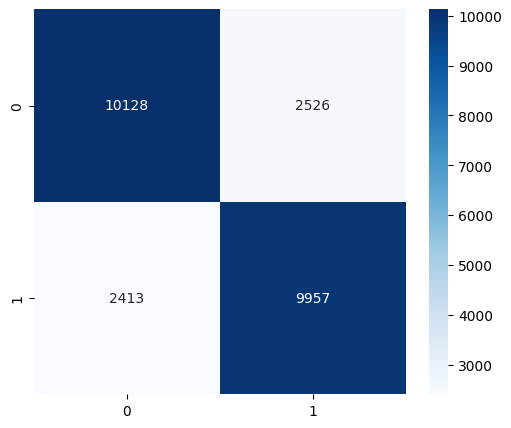

In [70]:
# TEST/EVALUATION FUNCTIONS
def get_device_safe(model):
    try:
        return next(model.parameters()).device
    except:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def test_binary_classification(model, test_loader, device=None):
    device = device or get_device_safe(model)
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            X, y, lengths = batch if len(batch) == 3 else (*batch, None)
            X, y = X.to(device), y.to(device)
            if lengths is not None:
                lengths = lengths.to(device)
            # Get embeddings using forward with labels=None
            embeddings = model(X, labels=None, lengths=lengths)
            W = F.normalize(model.aamsm.weight, dim=1)
            logits = embeddings @ W.T * model.aamsm.s
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    
    print(f"📊 Accuracy: {accuracy:.4f}")
    print(classification_report(all_labels, all_preds, target_names=["Outsider", "Group Member"], digits=4))
    
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        far = fp / (fp + tn) if (fp + tn) > 0 else 0
        frr = fn / (fn + tp) if (fn + tp) > 0 else 0
        print(f"FAR: {far:.4f} | FRR: {frr:.4f}")
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.show()
    return {"accuracy": accuracy, "confusion_matrix": cm}

def test_speaker_identification(model, test_loader, speaker_mapping=None, device=None):
    device = device or get_device_safe(model)
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            X, y, lengths = batch if len(batch) == 3 else (*batch, None)
            X, y = X.to(device), y.to(device)
            if lengths is not None:
                lengths = lengths.to(device)
            # Get embeddings using forward with labels=None
            embeddings = model(X, labels=None, lengths=lengths)
            W = F.normalize(model.aamsm.weight, dim=1)
            logits = embeddings @ W.T * model.aamsm.s
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"📊 Speaker Identification Accuracy: {accuracy:.4f}")
    return {"accuracy": accuracy, "predictions": all_preds, "labels": all_labels}

def test_model_auto(model, test_loader, meta, threshold=0.7, device=None):
    label_mode = meta.get("label_mode", "speaker_id")
    print(f"🔍 Label mode: {label_mode}")
    
    if label_mode == "binary":
        return test_binary_classification(model, test_loader, device)
    else:
        return test_speaker_identification(model, test_loader, meta.get("speaker_mapping"), device)

# RUN EVALUATION
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
meta = get_yaml_meta(dataset_path)
no_mels = meta["preprocessing_config"]["n_mels"]
num_classes = meta.get("num_classes", meta["total_speakers"])

backbone = Backbone(no_mels=no_mels, embed_dim=256, rnn_hidden=256, rnn_layers=2, bidir=True)
model = SpeakerClassifier(backbone, num_speakers=num_classes, aamsm_scaler=30.0, aamsm_margin=0.25)
state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

# Use cached loader for faster test evaluation (loads test set into RAM)
print("📦 Loading test set into RAM...")
test_loaders = build_h5_loaders_cached(
    dataset_path, splits=("test",), 
    batch_sizes={"test": 512},  # Larger batch size for faster inference
    pin_memory=True, shuffle_train=False
)
test_loader = test_loaders["test"]

results = test_model_auto(model, test_loader, meta=meta, device=device)
